In [1]:
pip install torchmetrics livelossplot monai opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 10.4 MB/s  0:00:07m0:00:0100:01

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import time
 
import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.utils.class_weight import compute_class_weight
 
import torch
import torch.nn as nn
from monai.config import print_config
from monai.data import DataLoader, decollate_batch
from monai.losses import FocalLoss
from monai.metrics import ROCAUCMetric
from monai.transforms import (Activations, AsDiscrete, Compose,
                               EnsureChannelFirst, Lambda, LoadImage,
                               NormalizeIntensity, RandAdjustContrast,
                               RandFlip, RandGaussianNoise,
                               RandGaussianSmooth, RandRotate, RandZoom,
                               Resize, ToTensor)
from monai.utils import set_determinism
from torch.utils.data import Dataset
from torchmetrics.classification import MulticlassF1Score
from torchvision.models import efficientnet_b4
 
# livelossplot pode não estar disponível em todos os ambientes
try:
    from livelossplot import PlotLosses
    from livelossplot.outputs import MatplotlibPlot
    LIVELOSS_AVAILABLE = True
except ImportError:
    LIVELOSS_AVAILABLE = False
    print("livelossplot não disponível — será usada alternativa simples.")

In [3]:
%matplotlib inline

In [4]:
# 1. REPRODUTIBILIDADE

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
np.random.seed(0)
set_determinism(seed=0)
set_seed(42)
print_config()

MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.12.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /mounts/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.15.3
Pillow version: 12.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.27.0+cu130
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT IN

In [6]:
# 2. CONFIGURAÇÃO GLOBAL
BASE_DIR      = './dataset'
PHASES        = ['train', 'val', 'test']
IMG_SIZE      = 512
BATCH_SIZE    = 16       # era 4 → mais estabilidade no gradiente
NUM_WORKERS   = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# Hiperparâmetros de treino
EPOCHS_PHASE1 = 10       # só o classificador congelado
EPOCHS_PHASE2 = 60       # fine-tuning completo
LR_CLASSIFIER = 1e-3
LR_FEATURES   = 1e-5
LR_HEAD       = 1e-4
WEIGHT_DECAY  = 1e-4
EARLY_STOP    = 12
FOCAL_GAMMA   = 2.0
MIXUP_ALPHA   = 0.2
TTA_N         = 5        # número de passes TTA na avaliação final
 
MODEL_DIR  = './models'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, 'efficientnet_b4_melhorado.pth')
 
print(f"Device: {DEVICE}")
print(f"CUDA disponível: {torch.cuda.is_available()}")

Device: cuda
CUDA disponível: True


In [8]:
# 3. CARREGAMENTO E ANÁLISE DO DATASET
data = {phase: {'images': [], 'labels': []} for phase in PHASES}
class_names = sorted([
    x for x in os.listdir(os.path.join(BASE_DIR, 'train'))
    if os.path.isdir(os.path.join(BASE_DIR, 'train', x))
])
num_class = len(class_names)
print(f"Classes ({num_class}): {class_names}")
 
VALID_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
 
def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(BASE_DIR, phase, class_name)
        if not os.path.isdir(class_dir):
            continue
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith(VALID_EXTS)
        ]
        data[phase]['images'].extend(files)
        data[phase]['labels'].extend([i] * len(files))
 
for phase in PHASES:
    load_images_labels(phase)
 
for phase in PHASES:
    print(f"{phase.capitalize()} count = {len(data[phase]['images'])}")

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train count = 1067
Val count = 234
Test count = 267


In [9]:
data = {phase: {'images': [], 'labels': []} for phase in PHASES}
class_names = sorted([
    x for x in os.listdir(os.path.join(BASE_DIR, 'train'))
    if os.path.isdir(os.path.join(BASE_DIR, 'train', x))
])
num_class = len(class_names)
print(f"Classes ({num_class}): {class_names}")
 
VALID_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
 
def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(BASE_DIR, phase, class_name)
        if not os.path.isdir(class_dir):
            continue
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith(VALID_EXTS)
        ]
        data[phase]['images'].extend(files)
        data[phase]['labels'].extend([i] * len(files))
 
for phase in PHASES:
    load_images_labels(phase)
 
for phase in PHASES:
    print(f"{phase.capitalize()} count = {len(data[phase]['images'])}")

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train count = 1067
Val count = 234
Test count = 267


In [10]:
# 4. PRÉ-PROCESSAMENTO COM CLAHE
def apply_clahe(img):
    """
    Recebe tensor [C, H, W] float e devolve tensor [1, H, W] float
    após aplicação de CLAHE.
    """
    # Converter para uint8 [0-255]
    img_np = img.numpy()
    if img_np.ndim == 3:
        img_np = img_np[0]          # pegar primeiro canal
    img_np = img_np.astype(np.float32)
    mn, mx = img_np.min(), img_np.max()
    img_uint8 = ((img_np - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
 
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_uint8)
 
    return torch.tensor(img_clahe, dtype=torch.float32).unsqueeze(0)
 
 
def repeat_if_needed(img):
    """Converte tensor [1, H, W] para [3, H, W] repetindo o canal."""
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img


In [11]:
# ── Transforms ───────────────────────────────────────────────────────────────
 
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    Lambda(apply_clahe),                                   # NOVO: CLAHE
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),     # zoom range alargado
    RandFlip(spatial_axis=1, prob=0.5),                   # NOVO: flip horizontal
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    RandGaussianSmooth(sigma_x=(0.5, 1.0), prob=0.2),    # NOVO: blur suave
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor(),
])
 
val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    Lambda(apply_clahe),                                   # NOVO: CLAHE também na val
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor(),
])
 
# Para TTA: transform com augmentação aleatória leve
tta_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    Lambda(apply_clahe),
    RandRotate(range_x=10, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor(),
])
 
act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

In [12]:
# 5. DATASET E DATALOADERS

In [13]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms
 
    def __len__(self):
        return len(self.image_files)
 
    def __getitem__(self, index):
        image = self.transforms(self.image_files[index])
        return image, self.labels[index]
 
 
train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = MedNISTDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = MedNISTDataset(data['test']['images'],  data['test']['labels'],  val_transforms)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [14]:
# 6. CLASS WEIGHTS PARA DATASET DESBALANCEADO
labels_array  = np.array(data['train']['labels'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights: { {class_names[i]: f'{w:.3f}' for i, w in enumerate(class_weights)} }")

Class weights: {'Biliary_Leaks': '2.425', 'Lithiasis': '0.528', 'Normal': '1.354', 'Stricture': '1.046'}


In [15]:
# 7. MODELO: EfficientNet-B4

In [16]:
model = efficientnet_b4(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
model = model.to(DEVICE)
 
print(f"Modelo: EfficientNet-B4 | Parâmetros: {sum(p.numel() for p in model.parameters()):,}")

/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /mounts/mecd-ap-g6/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:06<00:00, 11.7MB/s]


Modelo: EfficientNet-B4 | Parâmetros: 17,555,788


In [17]:
# 8. MIXUP
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    """Aplica Mixup ao batch. Devolve imagens misturadas e ambos os targets."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    idx = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam
 
 
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [21]:
# 9. FUNÇÃO DE TREINO (com scheduler externo injectável)
def train_model(train_dl, val_dl, model, loss_function, optimizer,
                epochs, name, scheduler=None, use_mixup=True):
    """
    Treina o modelo e guarda o melhor checkpoint baseado no F1 macro de validação.
 
    Args:
        scheduler: instância de lr_scheduler (ReduceLROnPlateau ou outro).
                   Se None, não é usado.
        use_mixup: activar Mixup durante o treino.
    """
    early_stopping_patience = EARLY_STOP
    epochs_without_improvement = 0
    best_metric       = -1
    best_metric_epoch = -1
    best_train_f1     = 0.0
    metric_values     = []
 
    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(DEVICE)
    auc_metric = ROCAUCMetric()
 
    if LIVELOSS_AVAILABLE:
        liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}_loss.png")])
 
    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss      = 0.0
        running_corrects  = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=DEVICE)
        y_train      = torch.tensor([], dtype=torch.long,    device=DEVICE)
 
        for inputs, labels in train_dl:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
 
            if use_mixup and np.random.rand() < 0.5:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                outputs = model(inputs)
                loss    = mixup_criterion(loss_function, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss    = loss_function(outputs, labels)
 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
 
            running_loss     += loss.detach() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train      = torch.cat([y_pred_train, outputs], dim=0)
            y_train           = torch.cat([y_train, labels],       dim=0)
 
        epoch_loss   = running_loss / len(train_dl.dataset)
        epoch_acc    = running_corrects.float() / len(train_dl.dataset)
        f1_train_val = f1_metric(y_pred_train.argmax(dim=1), y_train)
 
        logs['loss']     = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1']       = f1_train_val.item()
 
        # ── Validação ────────────────────────────────────────────────────────
        model.eval()
        running_loss     = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=DEVICE)
        y      = torch.tensor([], dtype=torch.long,    device=DEVICE)
 
        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(DEVICE)
                val_labels = val_labels.to(DEVICE)
                outputs     = model(val_images)
                loss        = loss_function(outputs, val_labels)
                running_loss     += loss.detach() * val_images.size(0)
                _, preds          = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs],    dim=0)
                y      = torch.cat([y,      val_labels], dim=0)
 
            val_loss = running_loss / len(val_dl.dataset)
            val_acc  = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss']     = val_loss.item()
            logs['val_accuracy'] = val_acc.item()
 
            f1_val = f1_metric(y_pred.argmax(dim=1), y)
            logs['val_F1'] = f1_val.item()
 
            y_onehot     = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act   = [act(i)       for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            auc_result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(auc_result)
            logs['val_AUC'] = auc_result
 
            # ── Checkpoint ───────────────────────────────────────────────────
            if f1_val > best_metric:
                best_metric       = f1_val
                best_metric_epoch = epoch + 1
                best_train_f1     = f1_train_val.item()
                torch.save(model.state_dict(), name)
                print('  ✓ Novo melhor modelo guardado')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
 
            # ── ReduceLROnPlateau step ────────────────────────────────────────
            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(f1_val)
                else:
                    scheduler.step()
 
            # ── Early stopping ───────────────────────────────────────────────
            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"\n  Early stopping @ epoch {epoch + 1}"
                    f"  | Best Val F1: {best_metric:.4f} (epoch {best_metric_epoch})"
                )
                break
 
            print(
                f"  Epoch {epoch+1:03d}/{epochs}"
                f"  | AUC: {auc_result:.4f}"
                f"  | F1 train: {f1_train_val:.4f}"
                f"  | F1 val: {f1_val:.4f}"
                f"  | Best F1: {best_metric:.4f} (ep {best_metric_epoch})"
            )
 
        if LIVELOSS_AVAILABLE:
            liveloss.update(logs)
            liveloss.send()
 
    print(f"\n  Treino concluído | best F1: {best_metric:.4f} @ epoch {best_metric_epoch}")
    return best_metric

In [19]:
# 10. TREINO EM DUAS FASES

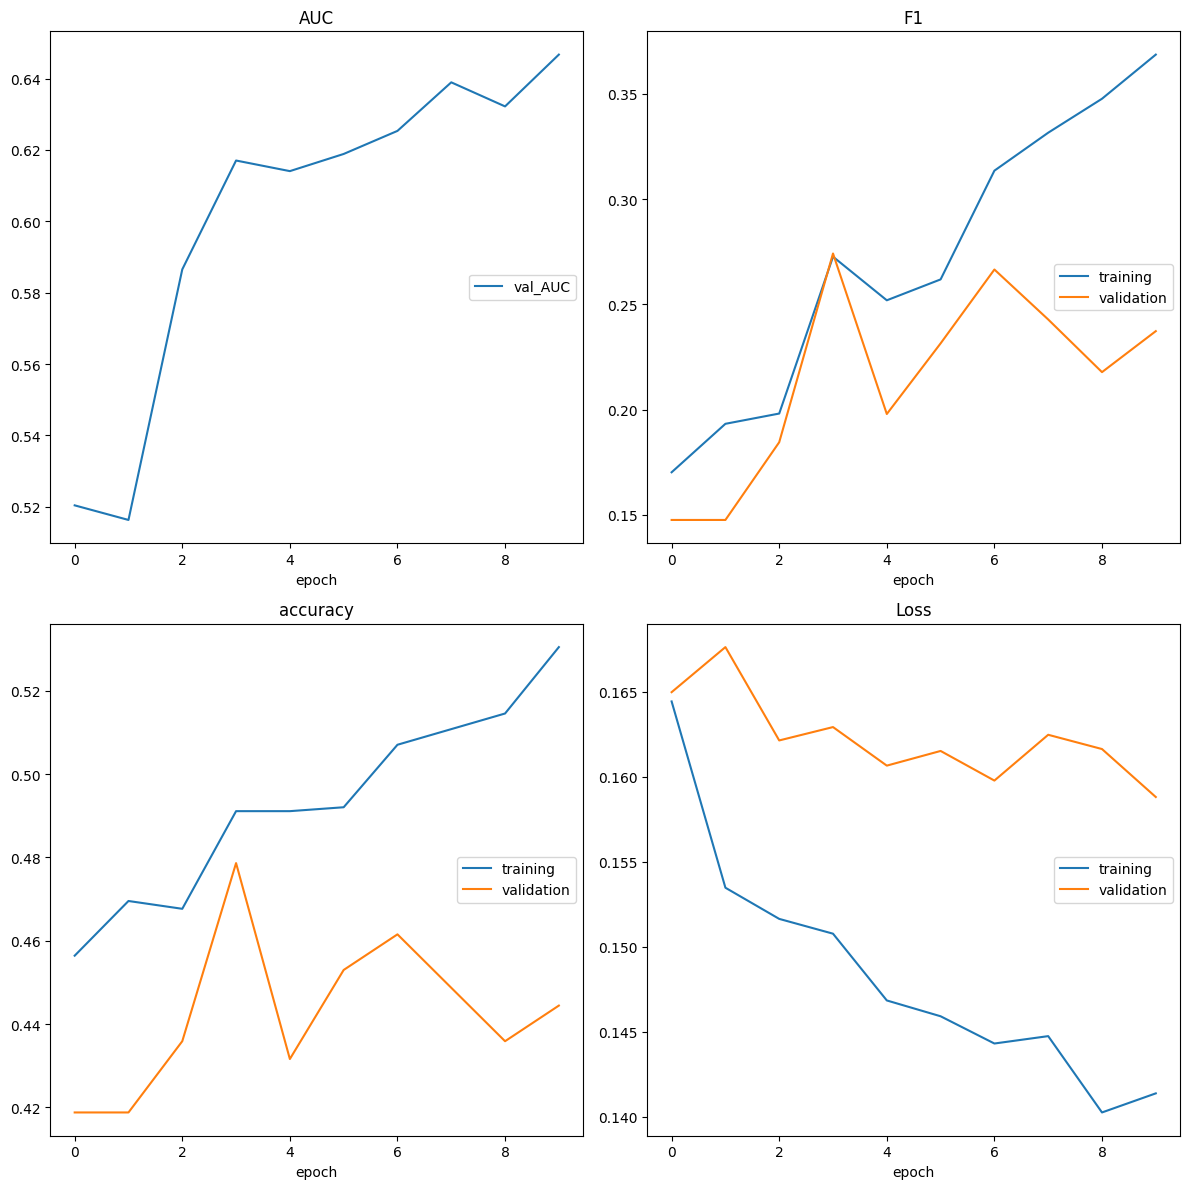


  Treino concluído | best F1: 0.2742 @ epoch 4
Fase 1 concluída em 70.8s


In [22]:
# ── Fase 1: Treinar só o classificador (features congeladas) ──────────────────
print("\n" + "="*60)
print("FASE 1: Treino do classificador (features congeladas)")
print("="*60)
 
for param in model.features.parameters():
    param.requires_grad = False
 
optimizer_phase1 = torch.optim.AdamW(
    model.classifier.parameters(), lr=LR_CLASSIFIER, weight_decay=WEIGHT_DECAY
)
scheduler_phase1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase1, mode='max', patience=3, factor=0.5
)
 
loss_function = FocalLoss(to_onehot_y=True, weight=weights_tensor, gamma=FOCAL_GAMMA)
 
starttime = time.perf_counter()
train_model(
    train_loader, val_loader, model, loss_function,
    optimizer_phase1, EPOCHS_PHASE1, MODEL_PATH,
    scheduler=scheduler_phase1, use_mixup=False   # sem mixup na fase 1
)
print(f"Fase 1 concluída em {time.perf_counter() - starttime:.1f}s")

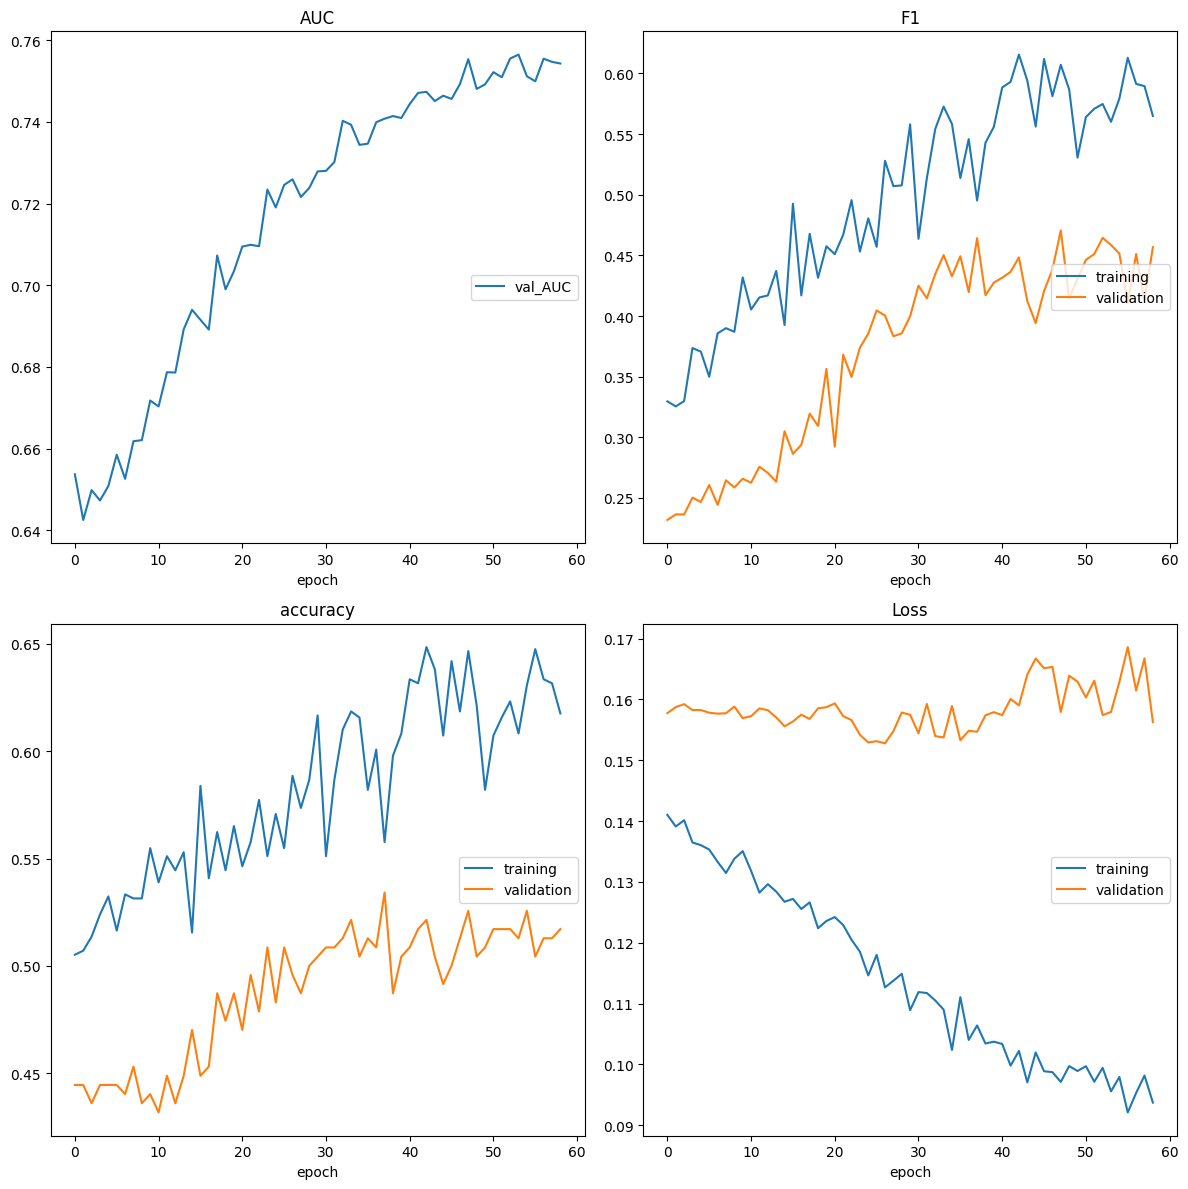


  Early stopping @ epoch 60  | Best Val F1: 0.4706 (epoch 48)

  Treino concluído | best F1: 0.4706 @ epoch 48
Fase 2 concluída em 1131.8s


In [23]:
# ── Fase 2: Fine-tuning completo com LRs diferenciados ───────────────────────
print("\n" + "="*60)
print("FASE 2: Fine-tuning completo (todas as camadas)")
print("="*60)
 
# Descongelar todas as camadas
for param in model.parameters():
    param.requires_grad = True
 
optimizer_phase2 = torch.optim.AdamW([
    {'params': model.features.parameters(),    'lr': LR_FEATURES},
    {'params': model.classifier.parameters(),  'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)
 
scheduler_phase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2, mode='max', patience=5, factor=0.5
)
 
starttime = time.perf_counter()
train_model(
    train_loader, val_loader, model, loss_function,
    optimizer_phase2, EPOCHS_PHASE2, MODEL_PATH,
    scheduler=scheduler_phase2, use_mixup=True
)
print(f"Fase 2 concluída em {time.perf_counter() - starttime:.1f}s")


AVALIAÇÃO SEM TTA
F1 Score (macro): 0.3550
Accuracy: 0.5318
               precision    recall  f1-score   support

Biliary_Leaks     0.0000    0.0000    0.0000        17
    Lithiasis     0.5440    0.8537    0.6646       123
       Normal     0.4516    0.3256    0.3784        43
    Stricture     0.6053    0.2738    0.3770        84

     accuracy                         0.5318       267
    macro avg     0.4002    0.3633    0.3550       267
 weighted avg     0.5138    0.5318    0.4857       267

[[  0   8   9   0]
 [  1 105   3  14]
 [  0  28  14   1]
 [  4  52   5  23]]


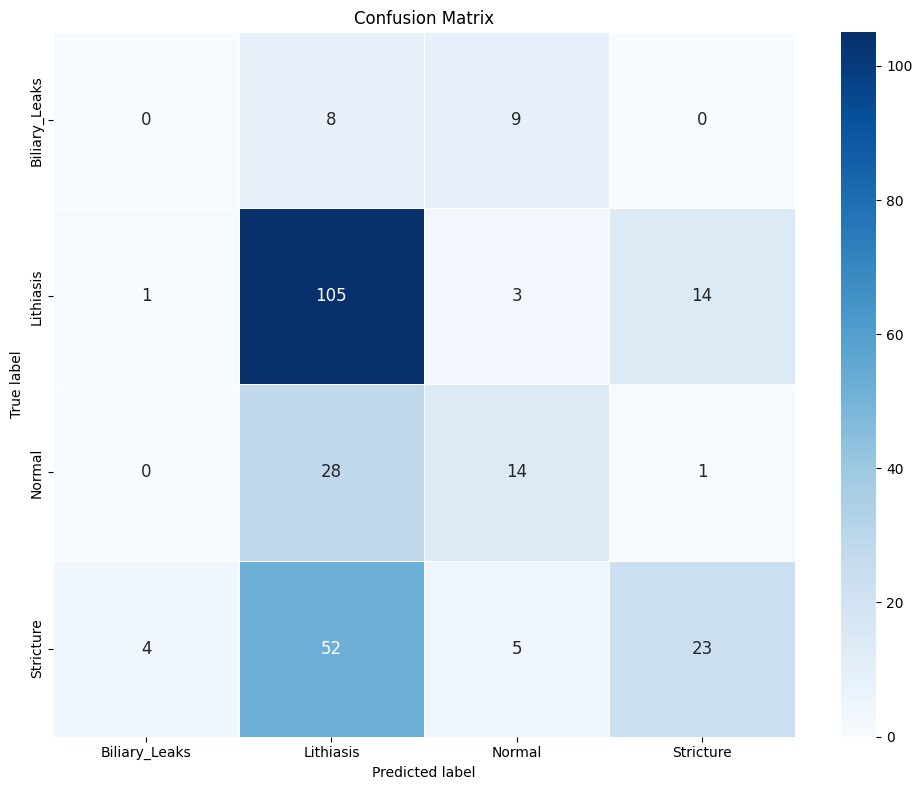


AVALIAÇÃO COM TTA (n=5)
F1 Score com TTA (macro): 0.4246
Accuracy (TTA): 0.5431
               precision    recall  f1-score   support

Biliary_Leaks     0.5714    0.2353    0.3333        17
    Lithiasis     0.5263    0.8943    0.6627       123
       Normal     0.6111    0.2558    0.3607        43
    Stricture     0.6061    0.2381    0.3419        84

     accuracy                         0.5431       267
    macro avg     0.5787    0.4059    0.4246       267
 weighted avg     0.5679    0.5431    0.4921       267



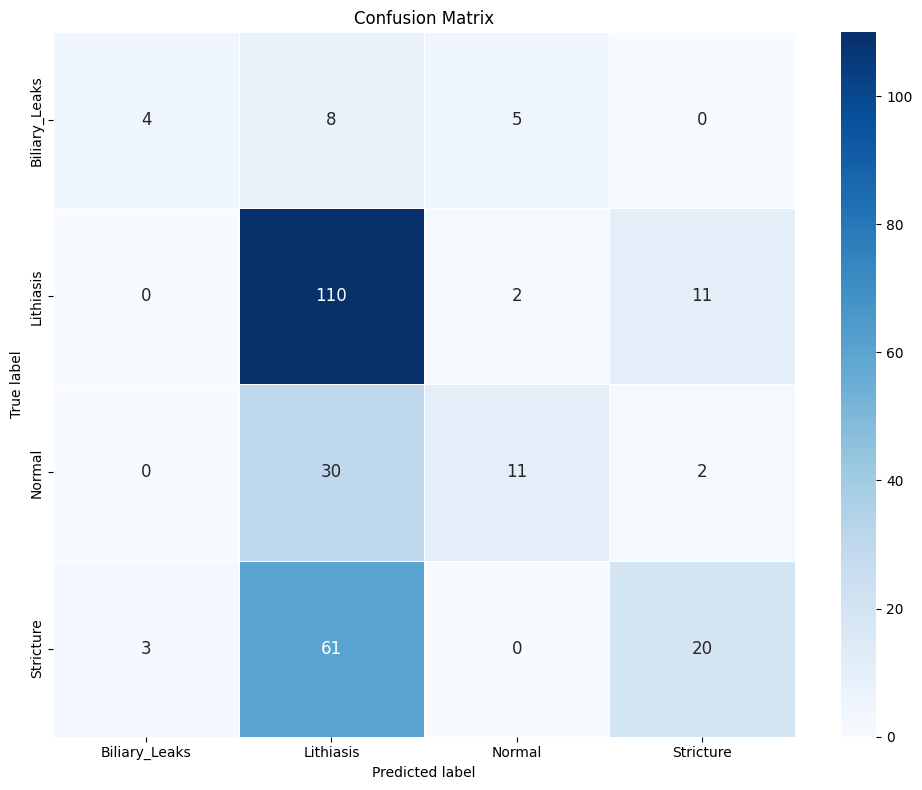

In [25]:
# 11. AVALIAÇÃO NO CONJUNTO DE TESTE
def evaluate_model(test_dl, model):
    """Avaliação simples (sem TTA)."""
    model.eval()
    predictions  = []
    actual_values = []
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs).detach().cpu().numpy()
            preds   = np.argmax(outputs, axis=1)
            predictions.append(preds.reshape(-1, 1))
            actual_values.append(labels.numpy().reshape(-1, 1))
    predictions   = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score (macro): {f1:.4f}")
    return actual_values, predictions
 
 
def evaluate_model_tta(image_files, labels_list, model, n=TTA_N):
    """
    Test-Time Augmentation: aplica n transformações aleatórias e faz média
    das probabilidades antes de tomar a decisão final.
    """
    model.eval()
    all_preds  = []
    all_labels = []
 
    for img_path, label in zip(image_files, labels_list):
        # Acumular logits de n passes
        logits_sum = None
        for _ in range(n):
            img_tensor = tta_transforms(img_path).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logit = torch.softmax(model(img_tensor), dim=1).cpu().numpy()
            if logits_sum is None:
                logits_sum = logit
            else:
                logits_sum += logit
        avg_logit = logits_sum / n
        pred      = np.argmax(avg_logit, axis=1)[0]
        all_preds.append(pred)
        all_labels.append(label)
 
    all_preds  = np.array(all_preds).reshape(-1, 1)
    all_labels = np.array(all_labels).reshape(-1, 1)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"F1 Score com TTA (macro): {f1:.4f}")
    return all_labels, all_preds
 
 
def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True,
        xticklabels=list_classes, yticklabels=list_classes,
        annot_kws={"size": 12}, fmt='g', linewidths=.5, cmap='Blues'
    )
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()
 
 
# ── Carregar melhor modelo guardado ──────────────────────────────────────────
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
 
print("\n" + "="*60)
print("AVALIAÇÃO SEM TTA")
print("="*60)
actual_values, predictions = evaluate_model(test_loader, model)
print(f"Accuracy: {accuracy_score(actual_values, predictions):.4f}")
print(classification_report(actual_values, predictions,
                             target_names=class_names, digits=4, zero_division=0))
 
cm = confusion_matrix(actual_values, predictions)
print(cm)
display_confusion_matrix(cm, class_names, MODEL_PATH.replace('.pth', ''))
 
print("\n" + "="*60)
print(f"AVALIAÇÃO COM TTA (n={TTA_N})")
print("="*60)
actual_tta, preds_tta = evaluate_model_tta(
    data['test']['images'], data['test']['labels'], model, n=TTA_N
)
print(f"Accuracy (TTA): {accuracy_score(actual_tta, preds_tta):.4f}")
print(classification_report(actual_tta, preds_tta,
                             target_names=class_names, digits=4, zero_division=0))
 
cm_tta = confusion_matrix(actual_tta, preds_tta)
display_confusion_matrix(cm_tta, class_names, MODEL_PATH.replace('.pth', '_tta'))


GRAD-CAM (Interpretabilidade)


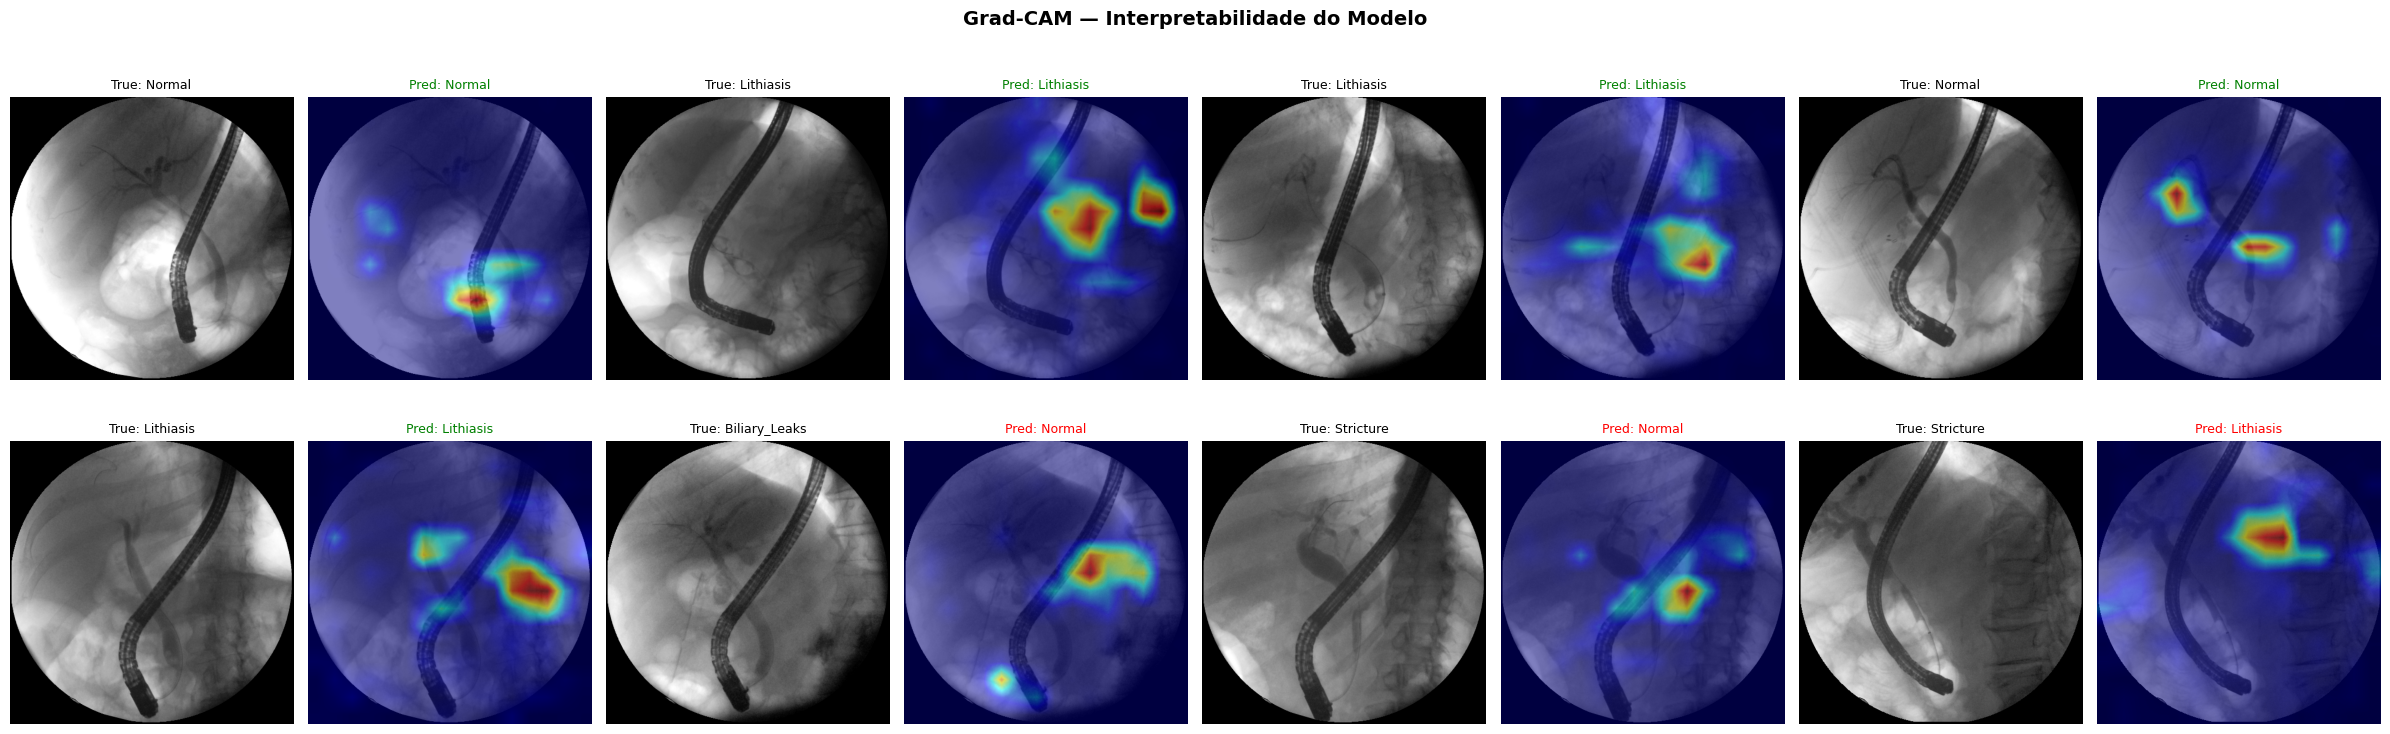

Grad-CAM guardado em models/gradcam_results.png

✅ Pipeline completo finalizado.


In [24]:
# 12. GRAD-CAM (Interpretabilidade — obrigatório no enunciado)
class GradCAM:
    """
    Implementação de Grad-CAM para EfficientNet.
    Utiliza a última camada convolucional do bloco features.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()
 
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
 
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
 
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
 
    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
 
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot)
 
        # Pesos = média global dos gradientes por canal
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
 
        # Redimensionar para tamanho da imagem
        cam = torch.nn.functional.interpolate(
            cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class
 
 
def visualize_gradcam(image_files, labels_list, model, n_samples=8):
    """Gera e mostra Grad-CAM para n_samples imagens do teste."""
    # Última camada convolucional do EfficientNet-B4
    target_layer = model.features[-1]
    gradcam      = GradCAM(model, target_layer)
 
    indices = np.random.choice(len(image_files), min(n_samples, len(image_files)), replace=False)
    cols    = 4
    rows    = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 6, rows * 4))
    axes = axes.flatten()
 
    for plot_idx, idx in enumerate(indices):
        img_path   = image_files[idx]
        true_label = labels_list[idx]
 
        # Pré-processar
        img_tensor = val_transforms(img_path).unsqueeze(0).to(DEVICE)
        img_tensor.requires_grad_(True)
 
        cam, pred_class = gradcam.generate(img_tensor)
        pred_label = class_names[pred_class]
        true_name  = class_names[true_label]
 
        # Imagem original
        orig = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        orig_np = np.array(orig)
 
        # Heatmap overlay
        heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (0.5 * orig_np + 0.5 * heatmap).astype(np.uint8)
 
        ax_orig = axes[plot_idx * 2]
        ax_cam  = axes[plot_idx * 2 + 1]
 
        ax_orig.imshow(orig_np, cmap='gray' if orig_np.ndim == 2 else None)
        ax_orig.set_title(f"True: {true_name}", fontsize=9)
        ax_orig.axis('off')
 
        ax_cam.imshow(overlay)
        color = 'green' if pred_class == true_label else 'red'
        ax_cam.set_title(f"Pred: {pred_label}", fontsize=9, color=color)
        ax_cam.axis('off')
 
    # Esconder axes extra
    for ax in axes[len(indices) * 2:]:
        ax.axis('off')
 
    plt.suptitle('Grad-CAM — Interpretabilidade do Modelo', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'gradcam_results.png'), dpi=200)
    plt.show()
    print("Grad-CAM guardado em models/gradcam_results.png")
 
 
print("\n" + "="*60)
print("GRAD-CAM (Interpretabilidade)")
print("="*60)
visualize_gradcam(data['test']['images'], data['test']['labels'], model, n_samples=8)
 
print("\n✅ Pipeline completo finalizado.")